## Model Training & Validation

In [1]:
%load_ext autoreload
%autoreload 2
%cd ../../..

/home/hal/workspace/clinical-ai-guardrails


/home/hal/workspace/clinical-ai-guardrails/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
# import warnings
# warnings.filterwarnings('ignore')

import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pypalettes import load_cmap
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from clinical_ai_guardrails.config import SEED

In [3]:
# --- Training data
train_X = pd.read_csv('data/ready/train/train.csv')
train_y = pd.read_csv('data/ready/train/train_labels.csv').iloc[:, 0]

# --- Test data
test_X = pd.read_csv('data/ready/train/test.csv')
test_y = pd.read_csv('data/ready/train/test_labels.csv').iloc[:, 0]

# Data checks
print(f"\nData:")
print(f"  • Training features shape: {train_X.shape}")
print(f"  • Training labels shape: {train_y.shape}")
print(f"  • Training labels distribution: {train_y.value_counts().to_dict()}")
print(f"  • Missing values in training: {train_X.isnull().sum().sum()}")
print("   " + "-"*10)
print(f"  • Test features shape: {test_X.shape}")
print(f"  • Test labels shape: {test_y.shape}")
print(f"  • Test labels distribution: {test_y.value_counts().to_dict()}")
print(f"  • Missing values in test: {test_X.isnull().sum().sum()}")

feature_groups = {
    'Clinical': [col for col in train_X.columns if 'GEPADO' in col or 'Illumina' in col],
    'Genomic': [col for col in train_X.columns if 'chr10' in col]
}


Data:
  • Training features shape: (42, 41)
  • Training labels shape: (42,)
  • Training labels distribution: {0: 21, 1: 21}
  • Missing values in training: 0
   ----------
  • Test features shape: (16, 41)
  • Test labels shape: (16,)
  • Test labels distribution: {0: 12, 1: 4}
  • Missing values in test: 0


## 1. Cross-Validation

In [18]:

models_configs = {
    'baseline': { 
        'max_depth': 1,
        'n_estimators': 50,
        'learning_rate': 0.03,
        'subsample': 1.0,
        'colsample_bytree': 1.0
    },
    'model_1': { 
        'n_estimators': 50,
        'learning_rate': 0.05,
        'max_depth': 2,
        'subsample': 0.5,
        'colsample_bytree': 0.3,
        'colsample_bylevel': 0.3,
        'gamma': 0.2,
        'reg_alpha': 2,
        'reg_lambda': 10
    },
    'model_2': { 
        'n_estimators': 50,
        'learning_rate': 0.01,
        'max_depth': 1,
        'subsample': 0.7,
        'colsample_bytree': 0.5
    },
    'model_3': { 
        'booster': 'dart',
        'max_depth': 3,
        'n_estimators': 50,
        'learning_rate': 0.05,
        'rate_drop': 0.1,
        'skip_drop': 0.5,
        'subsample': 0.9,
        'colsample_bytree': 0.9
    },
    'model_4': {
        'learning_rate': 0.19744472029067167,
        'max_depth': 6,
        'min_child_weight': 2,
        'subsample': 0.6060047115752186,
        'colsample_bytree': 0.699597883923433,
        'reg_alpha': 0.04667969832175275,
        'reg_lambda': 0.00014671564346191828
    }
}

cv = StratifiedKFold(n_splits=21, shuffle=True, random_state=SEED)
models = {}
for name, config in models_configs.items():
    i_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        **config
    )
    cv_metric = 'roc_auc' 
    i_cv_scores = cross_val_score(
        i_model, train_X, train_y, cv=cv, scoring=cv_metric
    )
    model = i_model.fit(train_X, train_y)  # Fit the model on the full training set
    models[name] = {
        'cv_scores': i_cv_scores,
        'model': model
    }
    print(f"• [{name}] CV {cv_metric}: {i_cv_scores.mean():.4f} (±{i_cv_scores.std():.4f})")


• [baseline] CV roc_auc: 0.9762 (±0.1065)
• [model_1] CV roc_auc: 1.0000 (±0.0000)
• [model_2] CV roc_auc: 1.0000 (±0.0000)
• [model_3] CV roc_auc: 0.9762 (±0.1065)
• [model_4] CV roc_auc: 0.9762 (±0.1065)


## 2. Test Set Evaluation

Show confusson matrix with large numbers in cells and without colorbar. Basic metrics

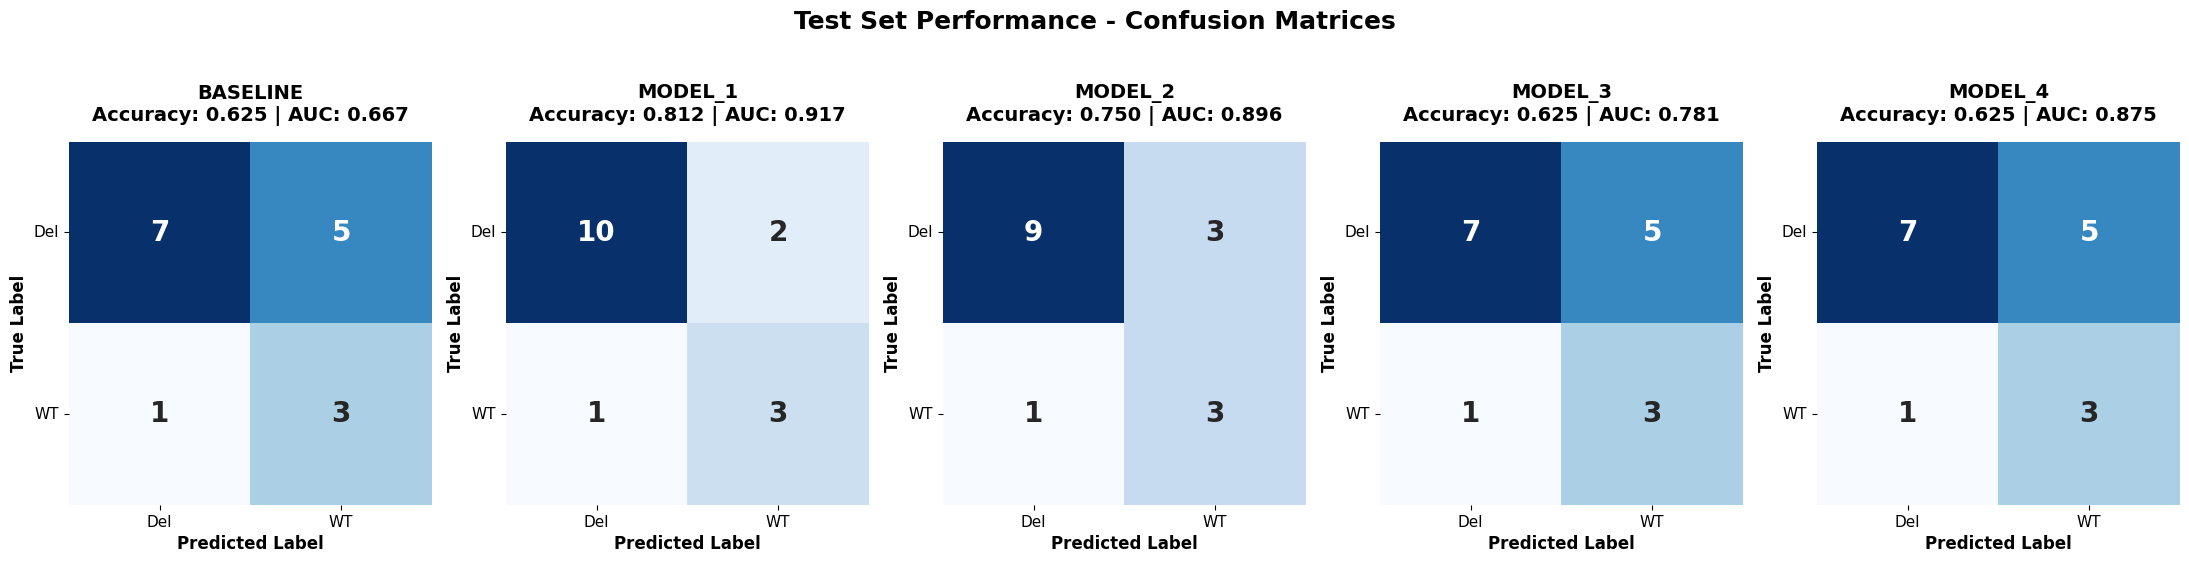


TEST SET EVALUATION METRICS
Model        Accuracy   Precision   Recall     F1-Score   ROC-AUC   
--------------------------------------------------------------------------------
baseline     0.6250     0.3750      0.7500     0.5000     0.6667    
model_1      0.8125     0.6000      0.7500     0.6667     0.9167    
model_2      0.7500     0.5000      0.7500     0.6000     0.8958    
model_3      0.6250     0.3750      0.7500     0.5000     0.7812    
model_4      0.6250     0.3750      0.7500     0.5000     0.8750    


In [28]:
test_results = {}

# --- Collect predictions
for name, model_info in models.items():
    model = model_info['model']
    
    y_pred = model.predict(test_X)
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    
    test_results[name] = {
        'accuracy': accuracy_score(test_y, y_pred),
        'precision': precision_score(test_y, y_pred, zero_division=0),
        'recall': recall_score(test_y, y_pred, zero_division=0),
        'f1': f1_score(test_y, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(test_y, y_pred_proba),
        'confusion_matrix': confusion_matrix(test_y, y_pred),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# --- Plots
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
axes = axes.ravel()

for i, (name, results) in enumerate(test_results.items()):
    cm = results['confusion_matrix']
    
    # Create confusion matrix plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                square=True, cbar=False, ax=axes[i],
                annot_kws={'size': 20, 'weight': 'bold'})
    
    axes[i].set_title(f'{name.upper()}\nAccuracy: {results["accuracy"]:.3f} | AUC: {results["roc_auc"]:.3f}', 
                      fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['Del', 'WT'], fontsize=11)
    axes[i].set_yticklabels(['Del', 'WT'], fontsize=11, rotation=0)

plt.suptitle('Test Set Performance - Confusion Matrices', 
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print detailed metrics table
print("\n" + "="*80)
print("TEST SET EVALUATION METRICS")
print("="*80)
print(f"{'Model':<12} {'Accuracy':<10} {'Precision':<11} {'Recall':<10} {'F1-Score':<10} {'ROC-AUC':<10}")
print("-" * 80)
for name, results in test_results.items():
    print(f"{name:<12} {results['accuracy']:<10.4f} {results['precision']:<11.4f} "
          f"{results['recall']:<10.4f} {results['f1']:<10.4f} {results['roc_auc']:<10.4f}")

## 3. Prospective Validation

In [25]:
pros_val_A_X = pd.read_csv('./data/ready/prospective/val_A.csv')
pros_val_A_y = pd.read_csv('./data/ready/prospective/val_A_labels.csv') # del, grey, WT

pros_val_B_X = pd.read_csv('./data/ready/prospective/val_B.csv')
pros_val_B_y = pd.read_csv('./data/ready/prospective/val_B_labels.csv') # del, grey, WT

label_mapping = {'del': 0, 'WT': 1}

def process_prospective_data(X, y, dataset_name):
    """Process prospective validation data by filtering out 'grey' labels"""
    # Get the label column (assuming first column contains labels)
    labels = y.iloc[:, 0] if hasattr(y.iloc[:, 0], 'map') else y.iloc[:, 0].astype(str)
    valid_mask = labels.isin(['del', 'WT'])
    
    if valid_mask.sum() == 0:
        print(f"Warning: No valid samples found in {dataset_name}")
        return None, None, None
    
    X_filtered = X[valid_mask].reset_index(drop=True)
    y_filtered = labels[valid_mask].map(label_mapping).reset_index(drop=True)
    
    print(f"\n{dataset_name}:")
    print(f"  • Original samples: {len(X)}")
    print(f"  • Valid samples (del/WT): {len(X_filtered)}")
    print(f"  • Grey samples excluded: {len(X) - len(X_filtered)}")
    print(f"  • Label distribution: {y_filtered.value_counts().to_dict()}")
    
    return X_filtered, y_filtered, valid_mask

val_A_X, val_A_y, val_A_mask = process_prospective_data(pros_val_A_X, pros_val_A_y, "Validation A")
val_B_X, val_B_y, val_B_mask = process_prospective_data(pros_val_B_X, pros_val_B_y, "Validation B")


Validation A:
  • Original samples: 9
  • Valid samples (del/WT): 8
  • Grey samples excluded: 1
  • Label distribution: {0: 8}

Validation B:
  • Original samples: 65
  • Valid samples (del/WT): 29
  • Grey samples excluded: 36
  • Label distribution: {0: 16, 1: 13}


In [26]:
def evaluate_prospective_validation(X, y, dataset_name, models_dict):
    """Evaluate all models on a prospective validation set"""
    if X is None or y is None:
        print(f"Skipping {dataset_name} - no valid data")
        return {}
    
    results = {}
    for name, model_info in models_dict.items():
        model = model_info['model']
        y_pred = model.predict(X)
        y_pred_proba = model.predict_proba(X)[:, 1]
        
        results[name] = {
            'accuracy': accuracy_score(y, y_pred),
            'precision': precision_score(y, y_pred, zero_division=0),
            'recall': recall_score(y, y_pred, zero_division=0),
            'f1': f1_score(y, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y, y_pred_proba) if len(np.unique(y)) > 1 else np.nan,
            'confusion_matrix': confusion_matrix(y, y_pred),
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
    return results

val_A_results = evaluate_prospective_validation(val_A_X, val_A_y, "Validation A", models)
val_B_results = evaluate_prospective_validation(val_B_X, val_B_y, "Validation B", models)

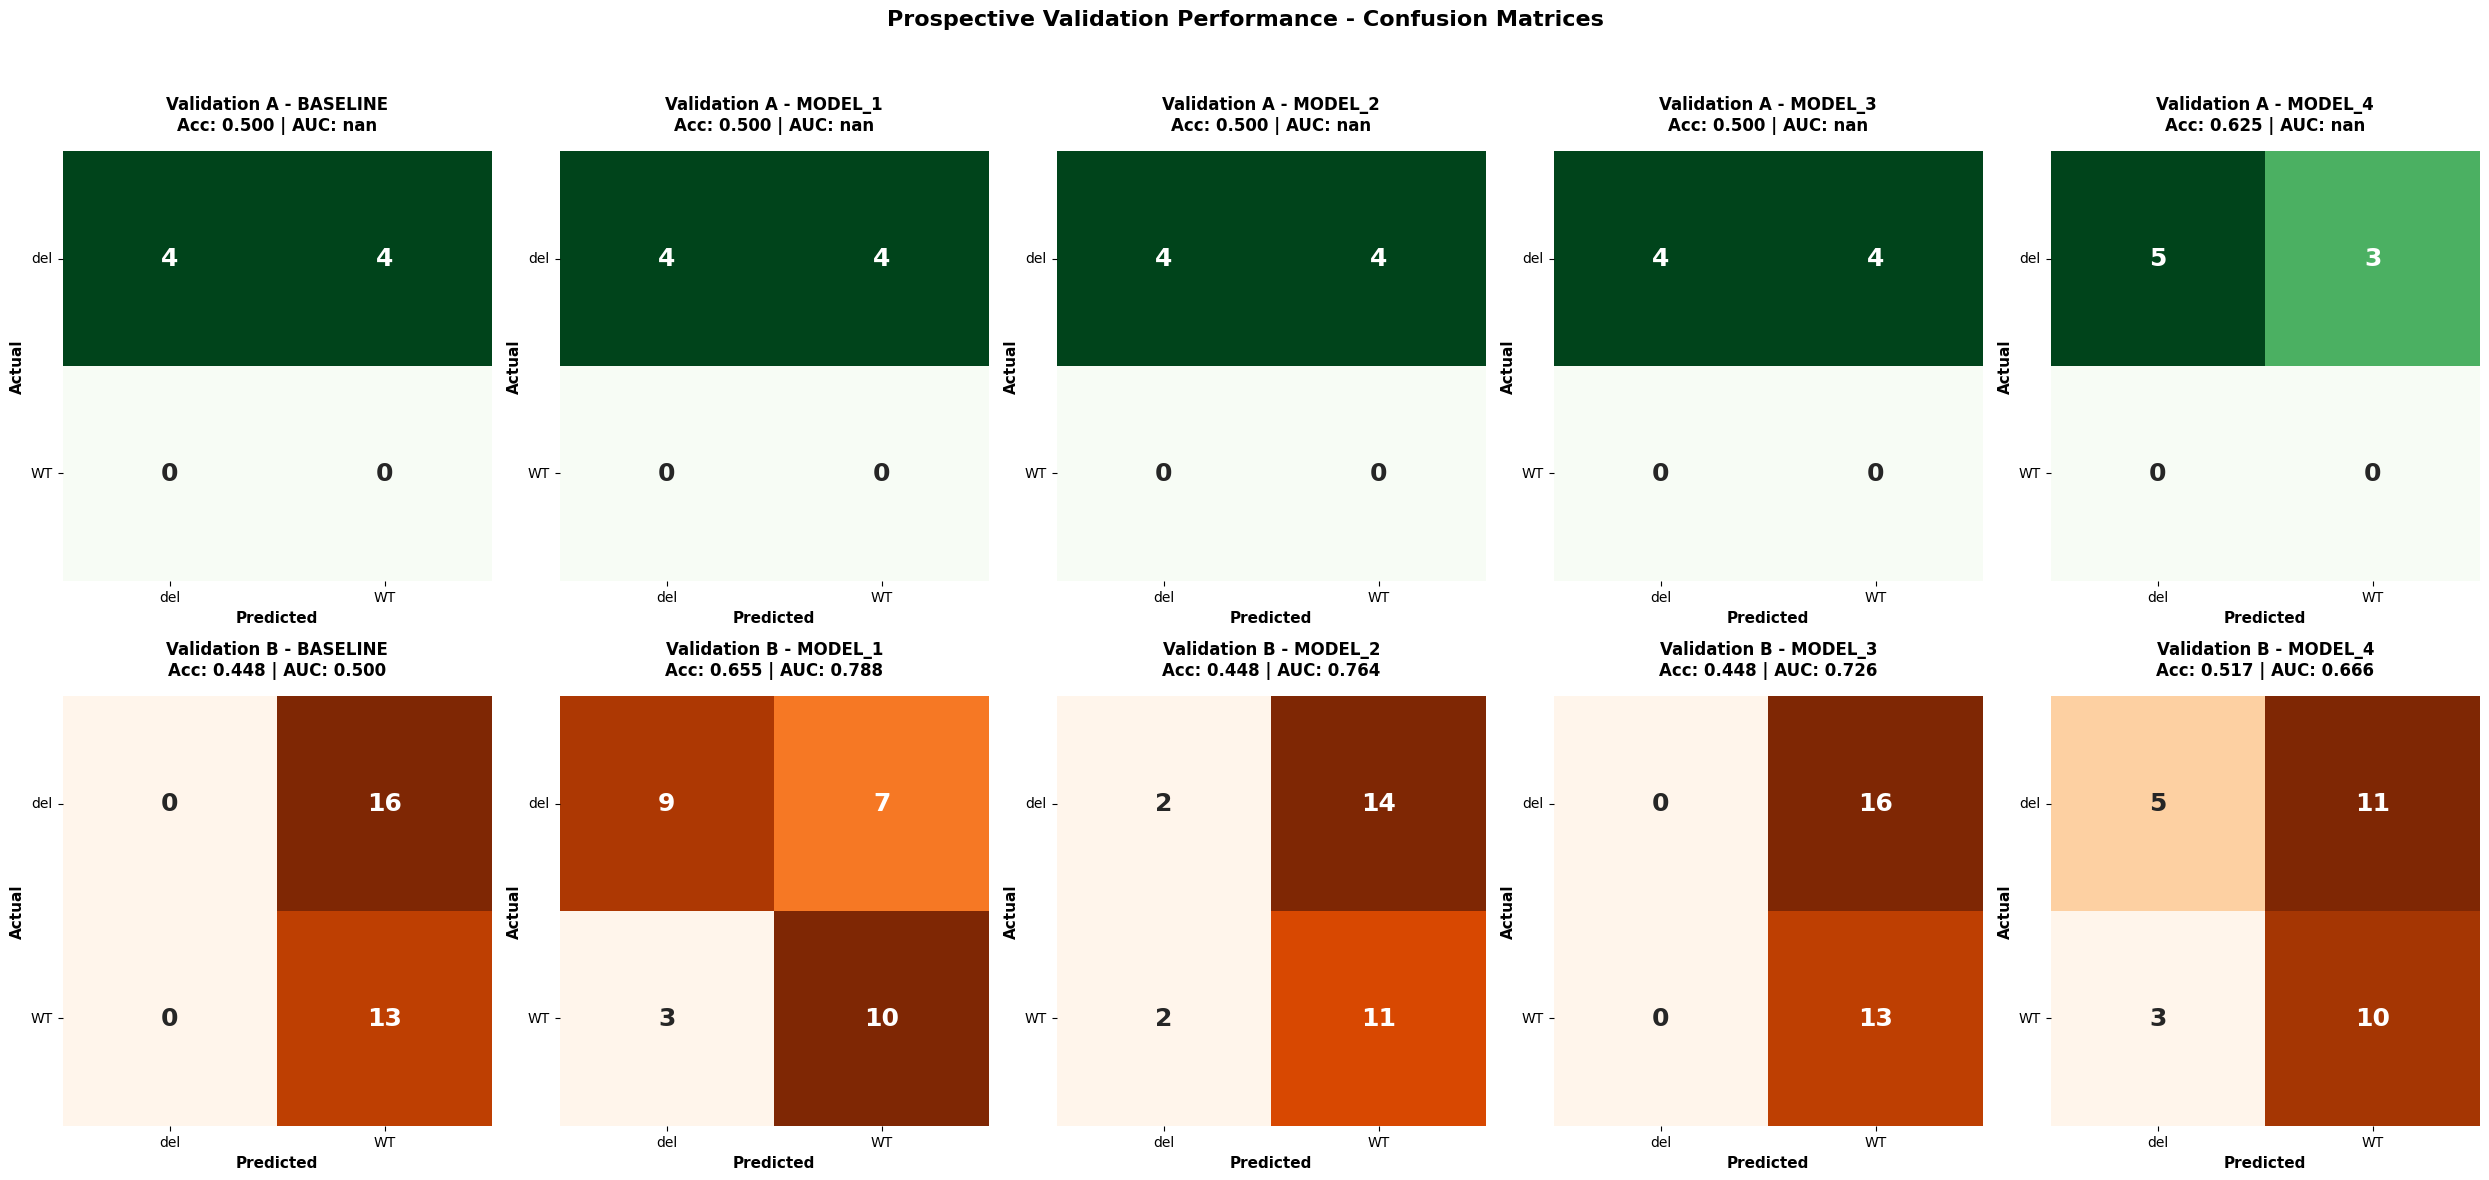

In [ ]:
def plot_prospective_validation_results(val_A_results, val_B_results):
    """Create confusion matrix plots for prospective validation"""
    
    has_val_A = bool(val_A_results)
    has_val_B = bool(val_B_results)
    
    if not has_val_A and not has_val_B:
        print("No prospective validation data available for plotting")
        return
    
    n_models = len(models_configs)
    n_datasets = sum([has_val_A, has_val_B])
    
    fig, axes = plt.subplots(n_datasets, n_models, figsize=(5*n_models, 6*n_datasets))
    
    if n_datasets == 1:
        axes = axes.reshape(1, -1)
    
    if has_val_A:
        row_idx = 0
        for col_idx, (name, results) in enumerate(val_A_results.items()):
            cm = results['confusion_matrix']
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                        square=True, cbar=False, ax=axes[row_idx, col_idx],
                        annot_kws={'size': 18, 'weight': 'bold'})
            
            axes[row_idx, col_idx].set_title(f'Validation A - {name.upper()}\n'
                                           f'Acc: {results["accuracy"]:.3f} | '
                                           f'AUC: {results["roc_auc"]:.3f}', 
                                           fontsize=12, fontweight='bold', pad=15)
            axes[row_idx, col_idx].set_xlabel('Predicted', fontsize=11, fontweight='bold')
            axes[row_idx, col_idx].set_ylabel('Actual', fontsize=11, fontweight='bold')
            axes[row_idx, col_idx].set_xticklabels(['del', 'WT'], fontsize=10)
            axes[row_idx, col_idx].set_yticklabels(['del', 'WT'], fontsize=10, rotation=0)
    
    if has_val_B:
        row_idx = 1 if has_val_A else 0
        for col_idx, (name, results) in enumerate(val_B_results.items()):
            cm = results['confusion_matrix']
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                        square=True, cbar=False, ax=axes[row_idx, col_idx],
                        annot_kws={'size': 18, 'weight': 'bold'})
            
            axes[row_idx, col_idx].set_title(f'Validation B - {name.upper()}\n'
                                           f'Acc: {results["accuracy"]:.3f} | '
                                           f'AUC: {results["roc_auc"]:.3f}', 
                                           fontsize=12, fontweight='bold', pad=15)
            axes[row_idx, col_idx].set_xlabel('Predicted', fontsize=11, fontweight='bold')
            axes[row_idx, col_idx].set_ylabel('Actual', fontsize=11, fontweight='bold')
            axes[row_idx, col_idx].set_xticklabels(['del', 'WT'], fontsize=10)
            axes[row_idx, col_idx].set_yticklabels(['del', 'WT'], fontsize=10, rotation=0)
    
    plt.suptitle('Prospective Validation Performance - Confusion Matrices', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_prospective_validation_results(val_A_results, val_B_results)

In [36]:
def print_summary():
    """Print a comprehensive summary of all validation results"""
    
    print("\n" + "="*100)
    print("MODEL PERFORMANCE SUMMARY")
    print("="*100)
    
    # Cross-validation results
    print(f"\n{'CROSS-VALIDATION (21-Fold Stratified)':<40}")
    print("-" * 100)
    print(f"{'Model':<12} {'Mean AUC':<12} {'Std AUC':<12} {'Min AUC':<12} {'Max AUC':<12}")
    print("-" * 100)
    for name, model_info in models.items():
        cv_scores = model_info['cv_scores']
        print(f"{name:<12} {cv_scores.mean():<12.4f} {cv_scores.std():<12.4f} "
              f"{cv_scores.min():<12.4f} {cv_scores.max():<12.4f}")
    
    # Test set results
    print(f"\n{'TEST SET EVALUATION':<40}")
    print("-" * 100)
    print(f"{'Model':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12}")
    print("-" * 100)
    for name, results in test_results.items():
        print(f"{name:<12} {results['accuracy']:<12.4f} {results['precision']:<12.4f} "
              f"{results['recall']:<12.4f} {results['f1']:<12.4f} {results['roc_auc']:<12.4f}")
    
    # Prospective validation results
    if val_A_results:
        print(f"\n{'PROSPECTIVE VALIDATION A':<40}")
        print("-" * 100)
        print(f"{'Model':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12}")
        print("-" * 100)
        for name, results in val_A_results.items():
            print(f"{name:<12} {results['accuracy']:<12.4f} {results['precision']:<12.4f} "
                  f"{results['recall']:<12.4f} {results['f1']:<12.4f} {results['roc_auc']:<12.4f}")
    
    if val_B_results:
        print(f"\n{'PROSPECTIVE VALIDATION B':<40}")
        print("-" * 100)
        print(f"{'Model':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12}")
        print("-" * 100)
        for name, results in val_B_results.items():
            print(f"{name:<12} {results['accuracy']:<12.4f} {results['precision']:<12.4f} "
                  f"{results['recall']:<12.4f} {results['f1']:<12.4f} {results['roc_auc']:<12.4f}")
    
    print("\n" + "="*100)

print_summary()


MODEL PERFORMANCE SUMMARY

CROSS-VALIDATION (21-Fold Stratified)   
----------------------------------------------------------------------------------------------------
Model        Mean AUC     Std AUC      Min AUC      Max AUC     
----------------------------------------------------------------------------------------------------
baseline     0.9762       0.1065       0.5000       1.0000      
model_1      1.0000       0.0000       1.0000       1.0000      
model_2      1.0000       0.0000       1.0000       1.0000      
model_3      0.9762       0.1065       0.5000       1.0000      
model_4      0.9762       0.1065       0.5000       1.0000      

TEST SET EVALUATION                     
----------------------------------------------------------------------------------------------------
Model        Accuracy     Precision    Recall       F1-Score     ROC-AUC     
----------------------------------------------------------------------------------------------------
baseline     0.62

/tmp/ipykernel_25908/357103435.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(loc="lower right", fontsize=10)


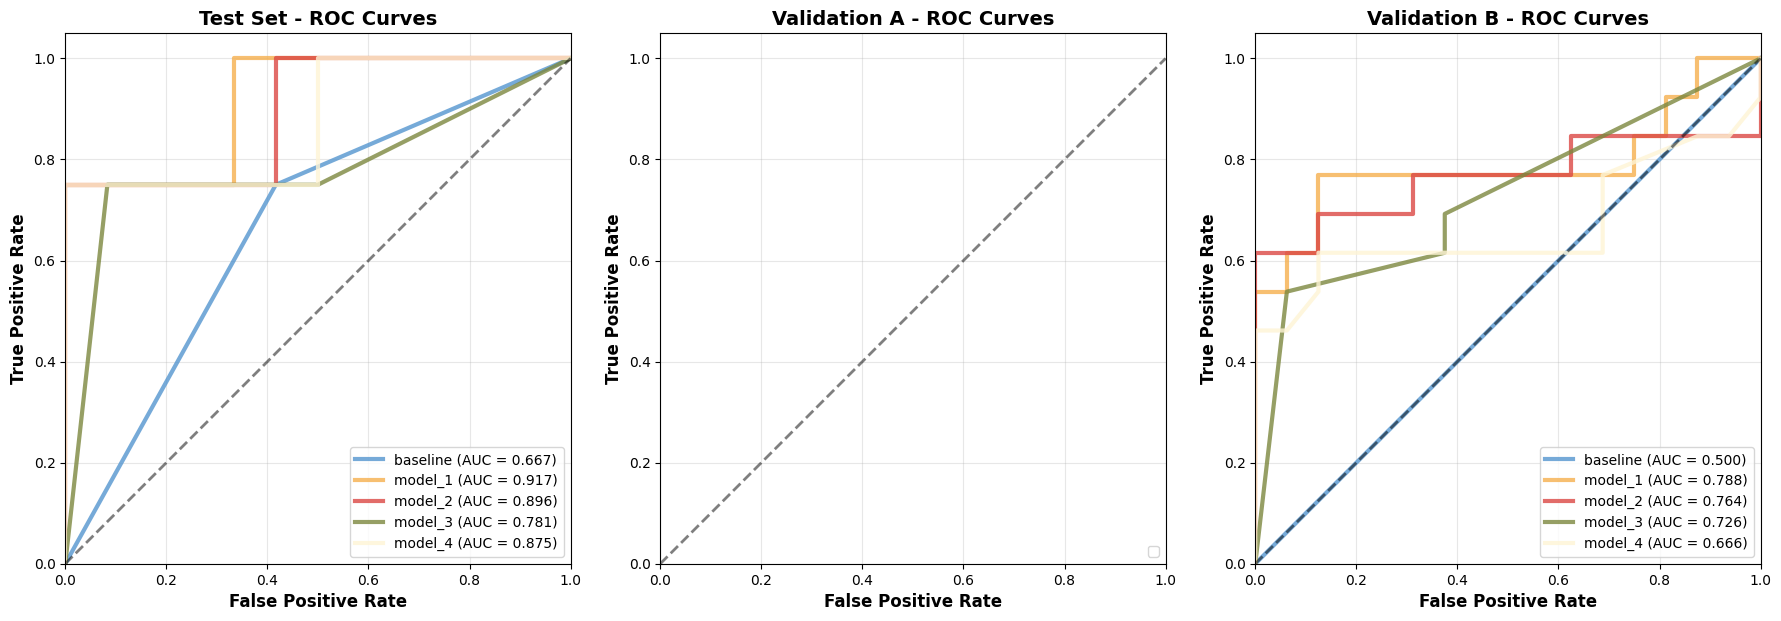

In [ ]:
def plot_roc_curves():
    """Create ROC curves for all validation sets"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    cmap = load_cmap('Badlands')
    datasets = [
        ("Test Set", test_results, test_y),
        ("Validation A", val_A_results, val_A_y),
        ("Validation B", val_B_results, val_B_y)
    ]
    
    for idx, (dataset_name, results, y_true) in enumerate(datasets):
        if not results or y_true is None:
            axes[idx].text(0.5, 0.5, f'No data available\nfor {dataset_name}', 
                          ha='center', va='center', fontsize=14, 
                          transform=axes[idx].transAxes)
            axes[idx].set_title(f'{dataset_name} - ROC Curves', fontsize=14, fontweight='bold')
            continue
        
        for i, (name, model_results) in enumerate(results.items()):
            if len(np.unique(y_true)) > 1:  # Only plot if we have both classes
                fpr, tpr, _ = roc_curve(y_true, model_results['y_pred_proba'])
                auc = model_results['roc_auc']
                
                axes[idx].plot(fpr, tpr, linewidth=3, alpha=0.8,
                              color=cmap.colors[i], 
                              label=f'{name} (AUC = {auc:.3f})')
        
        axes[idx].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=2)
        
        axes[idx].set_xlim([0.0, 1.0])
        axes[idx].set_ylim([0.0, 1.05])
        axes[idx].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
        axes[idx].set_title(f'{dataset_name} - ROC Curves', fontsize=14, fontweight='bold')
        axes[idx].legend(loc="lower right", fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

plot_roc_curves()